In [1]:
######################################
# Refine moisture budget analysis in -4K, CTL, and +4K
# 1. Make sure KW composite moisture term is normalized by KW precip std
#    -->Verify that qlf, dqlf/dt, wdq/dp@lf are still weaker in +4K after nomalization
#       Verify that wdqdp is the dmoinant term to explain the differences in qlf tendency in difference climates
# 2. Reorganize dignostic related to CLUBB shallow convection (CLUBB-induced temp and q tendency)
# 3. If the timing of CLUBB convection is later than wdq/dp, think about how vertical velocity induced by BL-wind convergence plays a role
#    -->Based on 2 and 3, conclude whether shallow convection or wind convergence dominates the vertical advection of moisture
# 4. Check moisture balance in the mean state, and find the dominant terms that maintain the balance. 
#    Think about how KWs perturb the balance and produce moisture tendency.
# 5. Lack some connection between lower tropospheric temp and shallow convection. Maybe calculate buoyancy.
#######################################################
#  2024.7.18 first written, updated 2024.9.20
# Mu-Ting Chien
##########################################

In [2]:
import os
import sys
sys.path.append('/glade/work/muting/function/')
import KW_diagnostics as KW
import mjo_mean_state_diagnostics as MJO
import create_my_colormap as mycolor
RWB = mycolor.red_white_blue()
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap # for plotting KW composite vertical structure

/glade/u/ssg/ch/usr/jupyterhub/envs/cmip6-201910a/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [3]:
dir_out            = '/glade/work/muting/KW/'
CASENAME_LIST2     = list(['SST_AQP3_Qobs_27_-4K',\
                          'SST_AQP3_Qobs_27',\
                          'SST_AQP3_Qobs_27_4K'])
CASENAME_SHORT_LIST = list(['-4K','CTL','4K'])
#output_dir_all = dir_out+'output_data/All_3hr_10yr/' # Previous directory
#output_dir_all_3yr = dir_out+'output_data/All_3hr_3yr/' # Previous directory
output_dir_all          = dir_out+'output_data/Paper4_20240822/' # updated directory
#figdir_all     = dir_out+'figure/Post_general/Paper4/' # Previous directory
figdir = dir_out+'figure/Post_general/Paper4_20240822/' #updated directory
figdir_supplement = figdir+'Supplement/'
os.makedirs(figdir,exist_ok=True) 
os.makedirs(output_dir_all,exist_ok=True) 
legend_list = list(['-4K','CTL','+4K']) # Change this if using nudging data

s2d = 86400
Cp = 1004.64
iyr_min = 2
iyr_max = 4
nyr = iyr_max-iyr_min+1
yr = np.arange(0,nyr)+1
latmax = 10

# Parameters for KW composite
PI = '\u03C0'
pi = np.pi
bin_simple = np.arange(-pi,pi+1/4*pi,1/4*pi)
bin_simple2 = np.arange(-pi,pi+1/2*pi,1/2*pi)
title = list(['(a) -4K','(b) CTL','(c) +4K'])

In [4]:
# Load EOF
data = np.load(output_dir_all+'EOF_all.npz')
EOFQ1 = data['EOFQ1'][2:-2,:]
EOFQ2 = data['EOFQ2'][2:-2,:]
plev  = data['plev'][2:-2]
nlev = np.size(plev)

In [13]:
# Load KW composite variables
save_kw_composite = 0 # already saved = 1, not yet saved = 0
normalize_by_kwamp_pr_T = 1 #0:no nomalization, 1:by PR, 2:by T

if save_kw_composite == 0:
    for icase in range(0,3):
        if icase != 1:
            CASENAME       = CASENAME_LIST2[icase]+'_3h_20y_CLUBB_new'
        else:
            CASENAME       = CASENAME_LIST2[icase]+'_3h_20y_CLUBB_new_uv_tendency'
        CASENAME_SHORT = CASENAME_SHORT_LIST[icase]+'_CLUBB_new'
        output_dir     = dir_out+'output_data/'+CASENAME+'/'
    
        # 0-1. Load KW amplitude (BY PRECIP)
        data  = np.load(output_dir+'precip_kw.npz') #other variables: time_pr, phase_correct
        phase = data['phase_bin']
        nphase = np.size(phase)
        if icase == 0:
            kwamp_all = np.empty([3])
            pr_KW_all = np.empty([nphase, 3])
        kwamp_pr = ( np.max(data['pr_kw'])-np.min(data['pr_kw']) )/2
        pr_KW_all[:,icase] = data['pr_kw']
        #print(kwamp)
        
        # 0.2. Load T KW (CALCULATE KW AMPLITUDE BY T2)
        data = np.load(output_dir+'T_kwcomposite.npz')
        if icase == 0:
            T_KW_all = np.empty([nphase, nlev, 3])
        T_KW_all[:,:,icase] = data['T_KW'][:,2:-2]#/kwamp
        kwamp_T = ( np.max( np.inner(T_KW_all[:,:,icase], EOFQ2[:,icase]) ) - np.min( np.inner(T_KW_all[:,:,icase], EOFQ2[:,icase]) ) )/2
        #print(kwamp_T)
    
        if normalize_by_kwamp_pr_T == 1:
            kwamp = kwamp_pr
        elif normalize_by_kwamp_pr_T == 2:
            kwamp = kwamp_T
        else:
            kwamp = 1
        kwamp_all[icase] = kwamp
    
        T_KW_all[:,:,icase] = T_KW_all[:,:,icase]#/kwamp
        
        # 1. Load KW composite q
        data      = np.load(output_dir+'q_kwcomposite.npz')
        phase     = data['phase']
        plev      = data['plev'][2:-2] # So that it has the same dimension with budget term below (75-950 hPa)
        nlev      = np.size(plev)
        nphase    = np.size(phase)
        if icase == 0:
            q_KW_all = np.empty([nphase, nlev, 3])
            q1000_KW_all = np.empty([nphase, 3])
        q_KW_all[:,:,icase] = data['q_KW'][:,2:-2]*1000#/kwamp 
        q1000_KW_all[:,icase] = data['q_KW'][:,-1]*1000#/kwamp
        
        # 2. Load KW composite moisture budget term
        data      = np.load(output_dir+'dqdt_udqdx_vdqdy_wdqdp_Q2_kwcomposite.npz')
        if icase == 0:
            #plev       = data['plev'][1:] # So that it has the same dimension with RH
            wdqdp_KW_all   = np.empty([nphase, nlev, 3])
            Q2moist_KW_all = np.empty([nphase, nlev, 3])
            dqdt_KW_all    = np.empty([nphase, nlev, 3])
            udqdx_KW_all   = np.empty([nphase, nlev, 3])
            vdqdy_KW_all   = np.empty([nphase, nlev, 3])
        Q2moist_KW_all[:,:,icase] = -data['Q2_KW'][:,1:]#/kwamp
        wdqdp_KW_all[:,:,icase]   = -data['wdqdp_KW'][:,1:]#/kwamp
        udqdx_KW_all[:,:,icase]   = -data['udqdx_KW'][:,1:]#/kwamp
        vdqdy_KW_all[:,:,icase]   = -data['vdqdy_KW'][:,1:]
        dqdt_KW_all[:,:,icase]    = data['dqdt_KW'][:,1:]#/kwamp
    
        # 3. Load KW composite du/dx and dv/dy
        data      = np.load(output_dir+'dudx_dvdy_kwcomposite.npz')
        if icase == 0:
            dudx_KW_all = np.empty([nphase, nlev, 3])
            dvdy_KW_all = np.empty([nphase, nlev, 3])
        dudx_KW_all[:,:,icase] = data['dudx_KW'][:,2:-1]#/kwamp # make sure it starts from 75 to 950 hPa
        dvdy_KW_all[:,:,icase] = data['dvdy_KW'][:,2:-1]#/kwamp
    
        # 4. Load Q clubb
        data      = np.load(output_dir+'dTdt_each_term_kwcomposite.npz')
        if icase == 0:
            Q_CLUBB_KW_all = np.empty([nphase, nlev, 3])
            Q_KW_all       = np.empty([nphase, nlev, 3]) #DTCOND
        Q_CLUBB_KW_all[:,:,icase] = data['STEND_CLUBB_KW'][:,2:-2]*s2d#/kwamp
        Q_KW_all[:,:,icase] = data['DTCOND_KW'][:,2:-2]*s2d#/kwamp
        
        # 5. Load omega and gph
        data = np.load(output_dir+'uvwz_kwcomposite.npz')
        if icase == 0:
            u_KW_all   = np.empty([nphase, nlev, 3])
            v_KW_all   = np.empty([nphase, nlev, 3])
            w_KW_all   = np.empty([nphase, nlev, 3])
            gph_KW_all = np.empty([nphase, nlev, 3])
            u1000_KW_all = np.empty([nphase, 3])
    
        u1000_KW_all[:,icase] = data['u_KW'][:,-1]#/kwamp
        u_KW_all[:,:,icase]   = data['u_KW'][:,2:-2]#/kwamp
        v_KW_all[:,:,icase]   = data['v_KW'][:,2:-2]#/kwamp
        w_KW_all[:,:,icase]   = data['w_KW'][:,2:-2]#/kwamp
        gph_KW_all[:,:,icase] = data['gph_KW'][:,2:-2]#/kwamp
    
        # 6. Load LH KW
        data = np.load(output_dir+'LH_kwcomposite.npz')
        if icase == 0:
            LH_KW_all = np.empty([nphase, 3])
        LH_KW_all[:,icase] = data['LH_KW']#/kwamp        
        
        # 7. Load ZMMU (updraft mass flux from ZM scheme)
        CASENAME2       = CASENAME_LIST2[icase]+'_DTCOND'
        output_dir2 = dir_out+'output_data/'+CASENAME2+'/'
        data  = np.load(output_dir2+'ZM_MP_kw.npz')
        if icase == 0:
            ZMMU_KW_all = np.empty([nphase, nlev, 3])
        ZMMU_KW_all[:,:,icase] = data['ZMMU_KW'][:,2:-2]#/kwamp # kg/m2/s
    
        ########################
        # load mean state T, Calculate RH KW
    
        for icase in range(0,3):
        
            if icase != 1:
                CASENAME       = CASENAME_LIST2[icase]+'_3h_20y_CLUBB_new'
            else:
                CASENAME       = CASENAME_LIST2[icase]+'_3h_20y_CLUBB_new_uv_tendency'
            output_dir = dir_out+'output_data/'+CASENAME+'/'
            data = np.load(output_dir+'QTUVZq.npz')
            plev_m = data['plev']
            nlev_m = np.size(plev_m)
            if icase == 0:
                Tm = np.empty([nlev, 3])
                qm = np.empty([nlev, 3])
                um = np.empty([nlev, 3])
            Tm[:,icase] = data['Tm'][2:-2]
            qm[:,icase] = data['qm'][2:-2]
            um[:,icase] = data['Um'][2:-2]
    
    Tm_KW = np.tile(Tm, (np.size(phase),1,1))
    qm_KW = np.tile(qm, (np.size(phase),1,1))
    um_KW = np.tile(um, (np.size(phase),1,1))
    
    T_KW_total = T_KW_all+Tm_KW
    q_KW_total = q_KW_all*0.001+qm_KW
    u_KW_total = u_KW_all+um_KW
    uspeed_KW_total = np.abs(u_KW_total)
    uspeed_KW_mean = np.mean(uspeed_KW_total, 0)
    uspeed_KW_all = uspeed_KW_total-uspeed_KW_mean
    
    e, qs_KW_total = KW.cc_equation(T_KW_total, plev)
    rh_KW_total = q_KW_total/qs_KW_total
    rh_KW_mean = np.mean(rh_KW_total, 0)
    rh_KW_mean = np.tile(rh_KW_mean, (nphase, 1, 1))
    rh_KW_all = rh_KW_total - rh_KW_mean
    
    qs_KW_mean = np.mean(qs_KW_total, 0)
    qs_KW_mean = np.tile(qs_KW_mean, (nphase, 1, 1))
    qs_KW_all = qs_KW_total - qs_KW_mean
    
    # Unit: q in g/kg, Q in K/day
    np.savez(output_dir_all+'KW_composite_3D_all.npz', T_KW_all=T_KW_all, q_KW_all=q_KW_all,\
             Q2moist_KW_all=Q2moist_KW_all, dqdt_KW_all=dqdt_KW_all, wdqdp_KW_all=wdqdp_KW_all, udqdx_KW_all=udqdx_KW_all, vdqdy_KW_all=vdqdy_KW_all,\
             dudx_KW_all=dudx_KW_all, dvdy_KW_all=dvdy_KW_all,\
             u_KW_all=u_KW_all, v_KW_all=v_KW_all, w_KW_all=w_KW_all, gph_KW_all=gph_KW_all,\
             uspeed_KW_total=uspeed_KW_total, uspeed_KW_all=uspeed_KW_all,
             Q_KW_all=Q_KW_all, Q_CLUBB_KW_all=Q_CLUBB_KW_all, ZMMU_KW_all=ZMMU_KW_all,\
            rh_KW_total=rh_KW_total, rh_KW_all=rh_KW_all, qs_KW_total=qs_KW_total, qs_KW_all=qs_KW_all, \
             plev=plev, phase=phase)
    
    np.savez(output_dir_all+'KW_composite_2D_all.npz', pr_KW_all=pr_KW_all, LH_KW_all=LH_KW_all,\
             u1000_KW_all=u1000_KW_all, q1000_KW_all=q1000_KW_all, phase=phase)
    
    np.savez(output_dir_all+'KW_amplitude_pr_all.npz', kwamp_all=kwamp_all)

    # Normalize by KW amp: 3D
    T_KW_all       = T_KW_all/kwamp_all
    q_KW_all       = q_KW_all/kwamp_all
    Q_KW_all       = Q_KW_all/kwamp_all
    Q_CLUBB_KW_all = Q_CLUBB_KW_all/kwamp_all
    Q2moist_KW_all = Q2moist_KW_all/kwamp_all
    dqdt_KW_all    = dqdt_KW_all/kwamp_all
    wdqdp_KW_all   = wdqdp_KW_all/kwamp_all
    udqdx_KW_all   = udqdx_KW_all/kwamp_all
    u_KW_all       = u_KW_all/kwamp_all
    v_KW_all       = v_KW_all/kwamp_all
    w_KW_all       = w_KW_all/kwamp_all
    gph_KW_all     = gph_KW_all/kwamp_all
    uspeed_KW_all  = uspeed_KW_all/kwamp_all
    ZMMU_KW_all    = ZMMU_KW_all/kwamp_all
    rh_KW_all      = rh_KW_all/kwamp_all
    qs_KW_all      = qs_KW_all/kwamp_all

    # Normalize by KW amp: 2D
    LH_KW_all    = LH_KW_all/kwamp_all
    u1000_KW_all = u1000_KW_all/kwamp_all
    q1000_KW_all = q1000_KW_all/kwamp_all

else:
    # Load KW amplitude
    data       = np.load(output_dir_all+'KW_amplitude_pr_all.npz')
    kwamp_all = data['kwamp_all']
    
    # Load KW composite 3D variables and normalize
    data           = np.load(output_dir_all+'KW_composite_3D_all.npz')
    T_KW_all       = data['T_KW_all']/kwamp_all
    q_KW_all       = data['q_KW_all']/kwamp_all
    Q2moist_KW_all = data['Q2moist_KW_all']/kwamp_all
    dqdt_KW_all    = data['dqdt_KW_all']/kwamp_all
    wdqdp_KW_all   = data['wdqdp_KW_all']/kwamp_all
    udqdx_KW_all   = data['udqdx_KW_all']/kwamp_all
    u_KW_all       = data['u_KW_all']/kwamp_all
    v_KW_all       = data['v_KW_all']/kwamp_all
    w_KW_all       = data['w_KW_all']/kwamp_all
    gph_KW_all     = data['gph_KW_all']/kwamp_all
    uspeed_KW_all  = data['uspeed_KW_all']/kwamp_all
    Q_KW_all       = data['Q_KW_all']/kwamp_all
    Q_CLUBB_kw_all = data['Q_CLUBB_KW_all']/kwamp_all
    ZMMU_KW_all    = data['ZMMU_KW_all']/kwamp_all
    rh_KW_all      = data['rh_KW_all']/kwamp_all
    qs_KW_all      = data['qs_KW_all']/kwamp_all
        
    # Load KW composite 2D variables and normalize
    data           = np.load(output_dir_all+'KW_composite_2D_all.npz')
    LH_KW_all      = data['LH_KW_all']/kwamp_all
    u1000_KW_all   = data['u1000_KW_all']/kwamp_all
    q1000_KW_all   = data['q1000_KW_all']/kwamp_all

'''
np.savez(output_dir_all+'RH_qs_kwcomposite_all.npz', rh_KW_total=rh_KW_total, rh_KW_all=rh_KW_all,\
         qs_KW_total=qs_KW_total, qs_KW_all=qs_KW_all,\
             plev=plev, phase=phase)

np.savez(output_dir_all+'uspeed_kwcomposite_all.npz', uspeed_KW_total=uspeed_KW_total, uspeed_KW_all=uspeed_KW_all,\
             plev=plev, phase=phase)
'''

"\nnp.savez(output_dir_all+'RH_qs_kwcomposite_all.npz', rh_KW_total=rh_KW_total, rh_KW_all=rh_KW_all,         qs_KW_total=qs_KW_total, qs_KW_all=qs_KW_all,             plev=plev, phase=phase)\n\nnp.savez(output_dir_all+'uspeed_kwcomposite_all.npz', uspeed_KW_total=uspeed_KW_total, uspeed_KW_all=uspeed_KW_all,             plev=plev, phase=phase)\n"

In [8]:
# Load KW frequency from 10-year data (caution!), start here
data = np.load(output_dir_all+'KW_amplitude_gr_Cp_all_10yr.npz')
freq_ave = data['freq_ave']
zwnum_ave = data['zwnum_ave']

In [11]:
# Calculate vertical mode decomposition
for icase in range(0,3):
    tmp1, tmp2 = KW.vertical_mode_decomposition(T_KW_all[:,:,icase], EOFQ1[:,icase], EOFQ2[:,icase])
    if icase == 0:
        T1_KW_all = np.empty([nphase, nlev, 3])
        T2_KW_all = np.empty([nphase, nlev, 3])
    T1_KW_all[:,:,icase] = tmp1
    T2_KW_all[:,:,icase] = tmp2

In [14]:
#######################################
# Find the average value over lf and bl
#######################################
# Find plev index for lower free troposphere and boundary layer

# Lower free troposphere
ilev_min_lf = np.argwhere(plev==750).squeeze()
ilev_max_lf = np.argwhere(plev==850).squeeze()

# Boundary layer
ilev_min_bl = np.argwhere(plev==850).squeeze()
ilev_max_bl = np.argwhere(plev==950).squeeze()

###########################
# This is used for KW composite line plot
nph = np.size(phase)
zero = np.zeros([nph])
##################################

qlf_KW_all = np.mean(q_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
qbl_KW_all = np.mean(q_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

dqdt_lf_KW_all = np.mean(dqdt_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
dqdt_bl_KW_all = np.mean(dqdt_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

wdqdp_lf_KW_all = np.mean(wdqdp_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
wdqdp_bl_KW_all = np.mean(wdqdp_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

Q2_lf_KW_all = np.mean(Q2moist_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
Q2_bl_KW_all = np.mean(Q2moist_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

udqdx_lf_KW_all = np.mean(udqdx_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
udqdx_bl_KW_all = np.mean(udqdx_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

wdqdp_Q2_udqdx_lf_KW_all = wdqdp_lf_KW_all+Q2_lf_KW_all+udqdx_lf_KW_all
wdqdp_Q2_udqdx_bl_KW_all = wdqdp_bl_KW_all+Q2_bl_KW_all+udqdx_bl_KW_all

wdqdp_Q2_lf_KW_all = wdqdp_lf_KW_all+Q2_lf_KW_all
wdqdp_Q2_bl_KW_all = wdqdp_bl_KW_all+Q2_bl_KW_all

Q_CLUBB_lf_KW_all = np.mean(Q_CLUBB_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
w_lf_KW_all       = np.mean(w_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
u_bl_KW_all       = np.mean(u_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

dudx_lf_KW_all    = np.mean(dudx_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
dudx_bl_KW_all    = np.mean(dudx_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

gph_lf_KW_all     = np.mean(gph_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
gph_bl_KW_all     = np.mean(gph_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

T_lf_KW_all  = np.mean(T_KW_all[:,  ilev_min_lf:ilev_max_lf+1, :], 1)
T1_lf_KW_all = np.mean(T1_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
T2_lf_KW_all = np.mean(T2_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)
#
T_bl_KW_all  = np.mean(T_KW_all[:,  ilev_min_bl:ilev_max_bl+1, :], 1)
T1_bl_KW_all = np.mean(T1_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)
T2_bl_KW_all = np.mean(T2_KW_all[:, ilev_min_bl:ilev_max_bl+1, :], 1)

rh_lf_KW_all = np.mean(rh_KW_all[:,  ilev_min_lf:ilev_max_lf+1, :], 1)
rh_bl_KW_all = np.mean(rh_KW_all[:,  ilev_min_bl:ilev_max_bl+1, :], 1)

uspeed_1000_KW_all = uspeed_KW_all[:,-1,:]

ZMMU_lf_KW_all = np.mean(ZMMU_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)

Q_lf_KW_all  = np.mean(Q_KW_all[:, ilev_min_lf:ilev_max_lf+1, :], 1)

In [15]:
######################
# Load data for Fig. 10 (Schematic)
#####################
ilev_lf_q = np.argwhere(plev==750).squeeze()
ilev_lf_gph = np.argwhere(plev==650).squeeze()
q_only_lf_KW_all                     = np.empty([nphase, nlev, 3])
q_only_lf_KW_all[:]                  = np.nan
q_only_lf_KW_all[:,ilev_lf_q:,:]     = q_KW_all[:,ilev_lf_q:,:]
gph_only_lf_KW_all                   = np.empty([nphase, nlev, 3])
gph_only_lf_KW_all[:]                = np.nan
gph_only_lf_KW_all[:,ilev_lf_gph:,:] = gph_KW_all[:,ilev_lf_gph:,:]
u_only_lf_KW_all                     = np.empty([nphase, nlev, 3])
u_only_lf_KW_all[:]                  = np.nan
u_only_lf_KW_all[:,ilev_lf_q:,:]     = u_KW_all[:,ilev_lf_q:,:]
w_only_lf_KW_all                     = np.empty([nphase, nlev, 3])
w_only_lf_KW_all[:]                  = np.nan
w_only_lf_KW_all[:,ilev_lf_q:,:]     = w_KW_all[:,ilev_lf_q:,:]

# Rescale the u by considering the wavelength
KW_zonal_wavelength = 2*np.pi*6371*1000/zwnum_ave # This is the physical distance of the x-axis in meter
u_norm = u_only_lf_KW_all/KW_zonal_wavelength
w_norm = w_only_lf_KW_all/(950-150)/100 # The below schematic starts from 950 to 150 hPa

done


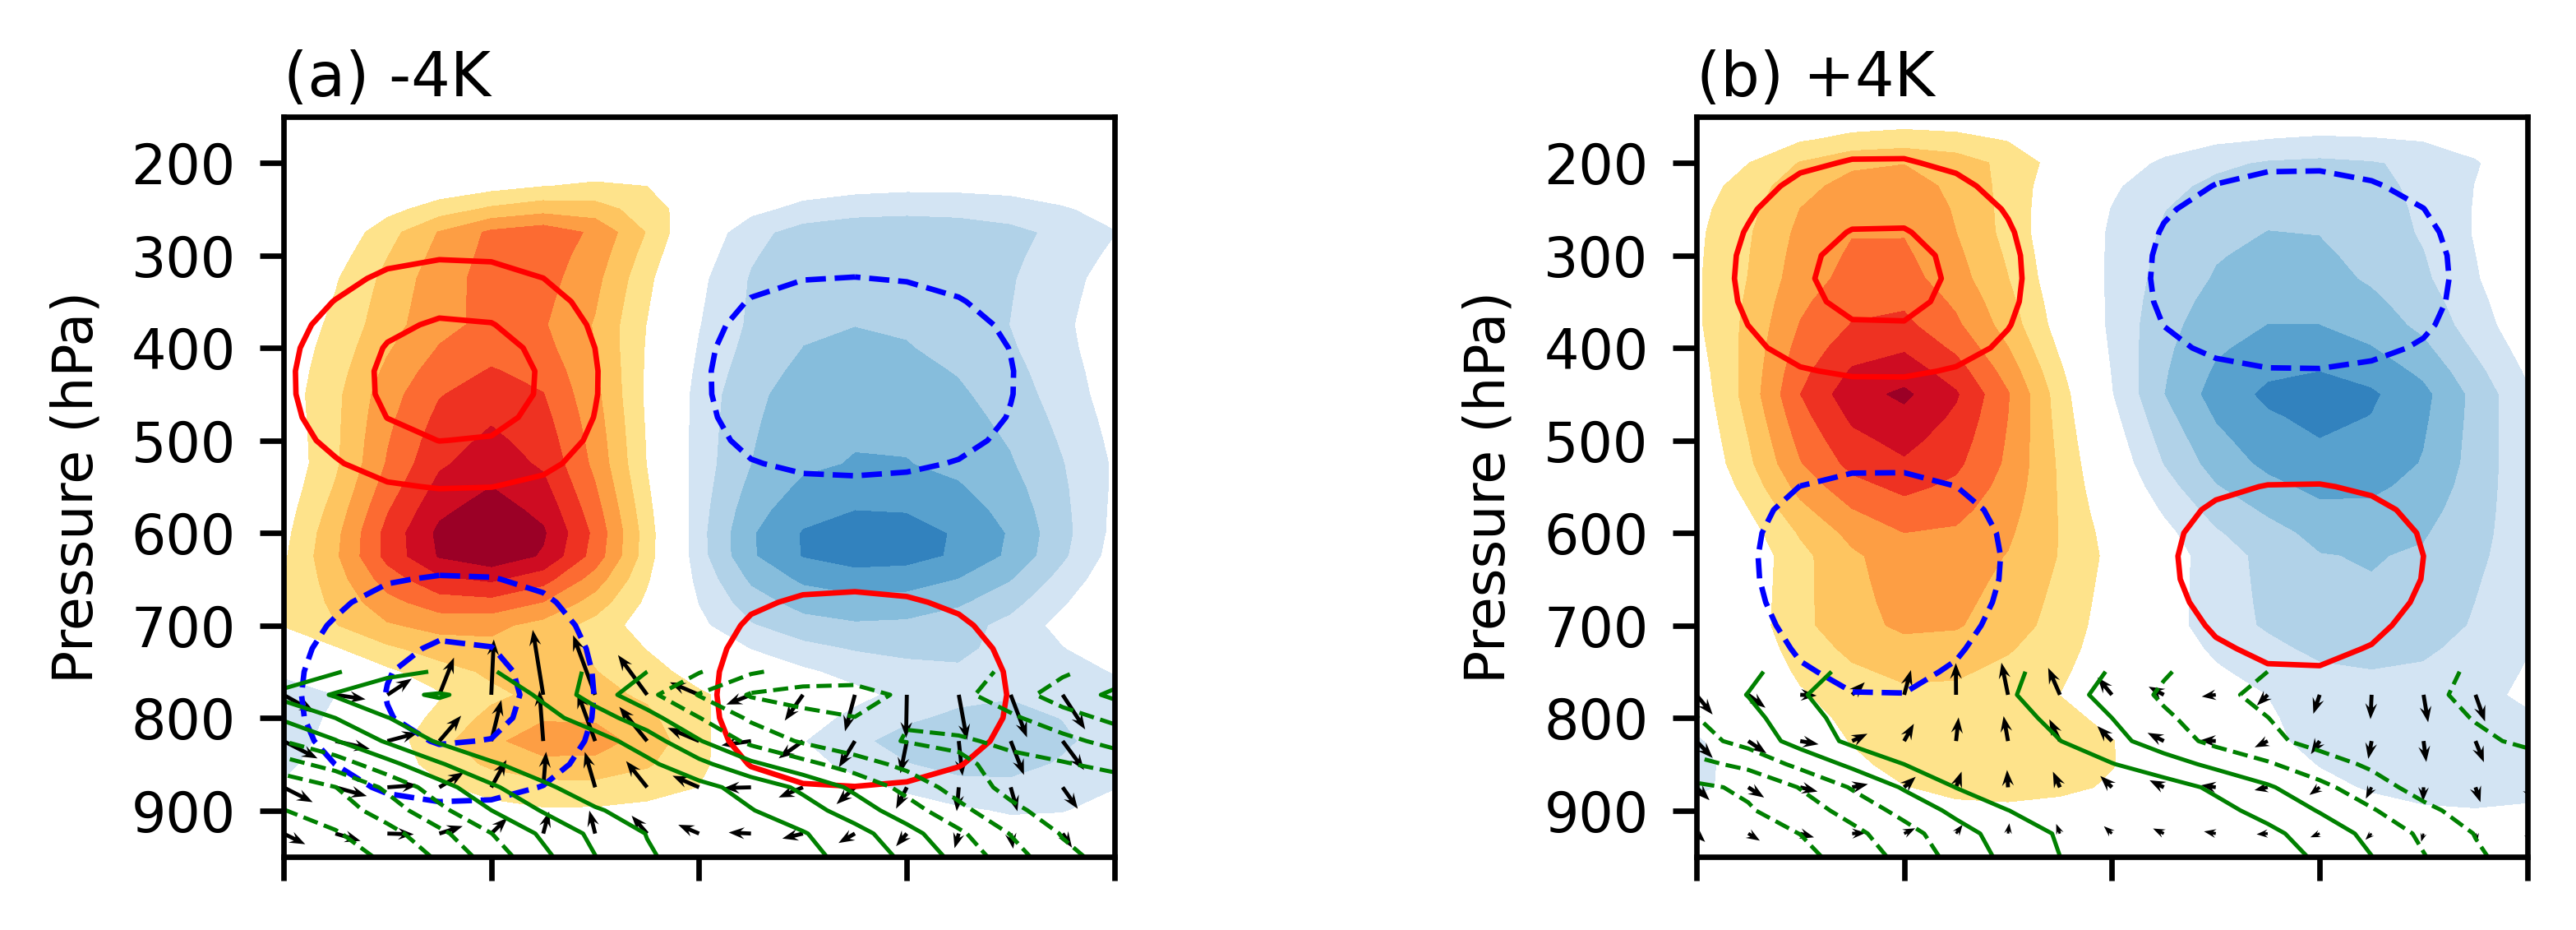

In [20]:
############################
# Fig.10: Plot schematic diagram (KW composite vertical structure of Q, T, q, uw)
##############################
title_noabc = list(['(a) -4K','CTL','(b) +4K'])
plot_cf_qTQ = 2 # or 0, if 0: plot q in contourf and T in contour; if 1: plot T in contourf and q in contour

clev_0 = 0
font = 8
i_list = np.array([0,2])

for plot_T_T1_T2 in range(2,3): # 0(T all) or 1(T1) or 2(T2) or 3(T1 and T2)
    
    fig,axes = plt.subplots(1,2,figsize=(6.5, 2),dpi=600)
    plt.subplots_adjust(left=0.2,right=0.9,top=0.9,bottom=0.15,wspace=0.7)
    plt.rcParams.update({'font.size': font})
    cn2_color = list(['g','k'])
    clev4_p = np.arange(0.8,2.4,0.8) #gph
    clev4_n = np.arange(-2.4,0,0.8) #gph
    var_cn4 = globals()['gph_only_lf_KW_all']
        
    for ii in range(0,2): #icase
        
        i = i_list[ii]
        plt.subplot(1,2,ii+1)
        ax = plt.gca()
        plt.title(title_noabc[i], pad=3, loc='left',fontsize=9)
        xx, yy = np.meshgrid(phase, plev)
        if plot_cf_qTQ==2:
            var_cn2 = globals()['q_only_lf_KW_all']
            if plot_T_T1_T2 == 2:
                var_cn = globals()['T2_KW_all']
                clev_n = np.arange(-0.21,0,0.03) # T
                clev_p = np.arange(0.03,0.24,0.03) # T
            var_cf = globals()['Q_KW_all']
            clev = np.arange(-0.8,0.9,0.1) # Q

            clev2_n = np.arange(-0.08,0,0.02)+0.01 # q
            clev2_p = np.arange(0.02,0.1,0.02)-0.01 # q
            # Plot Q
            cf  = plt.contourf(xx, yy, var_cf[:,:,i].T, levels=clev, cmap=get_cmap(RWB), extend='both' )
            # Plot T
            cn_p = plt.contour(xx, yy, var_cn[:,:,i].T, levels=clev_p, colors='r', linewidths=0.8)
            cn_n = plt.contour(xx, yy, var_cn[:,:,i].T, levels=clev_n, colors='b', linestyles='dashed',linewidths=0.8)
            #cn_0 = plt.contour(xx, yy, var_cn[:,:,i].T, levels=clev_0, colors='grey',linewidths=0.4)
            # Plot q
            cn2_p = plt.contour(xx, yy, var_cn2[:,:,i].T, levels=clev2_p, colors='g', linewidths=0.6)
            cn2_n = plt.contour(xx, yy, var_cn2[:,:,i].T, levels=clev2_n, colors='g', linestyles='dashed',linewidths=0.6)

        # Plot u and w (normalized by the physical legnth of x and y axis)
        skip = (slice(None, None, 2), slice(None, None, 1))
        skip2 = (slice(None, None, 1), slice(None, None, 2))
        u_norm_tmp = u_norm[:,:,i]
        w_norm_tmp = w_norm[:,:,i]
        plt.quiver(xx[skip], yy[skip], u_norm_tmp[skip2].T, -w_norm_tmp[skip2].T,units='inches',scale=1.5*10**(-6), \
                   width=0.008, headwidth=3, headlength=4, headaxislength=3)#, pivot='middle')
        
        plt.ylim([150,np.max(plev)])
        plt.yticks(np.arange(200,1000,100))
        plt.gca().invert_yaxis()
        plt.xticks(np.arange(-pi,pi+pi/2,pi/2),(PI,PI+'/2','0','-'+PI+'/2','-'+PI),fontsize=font)
        plt.tick_params(bottom=True,top=False,left=True,right=False)
        plt.tick_params(labelbottom=False,labeltop=False,labelleft=True,labelright=False)
        ax.yaxis.set_label_position("left")
        ax.set_ylabel('Pressure (hPa)',fontsize=font)
    if plot_T_T1_T2 == 2:
        print('done')
        plt.savefig(figdir+'Fig.10_Schematic_T2.png',dpi=600)  
    plt.show()

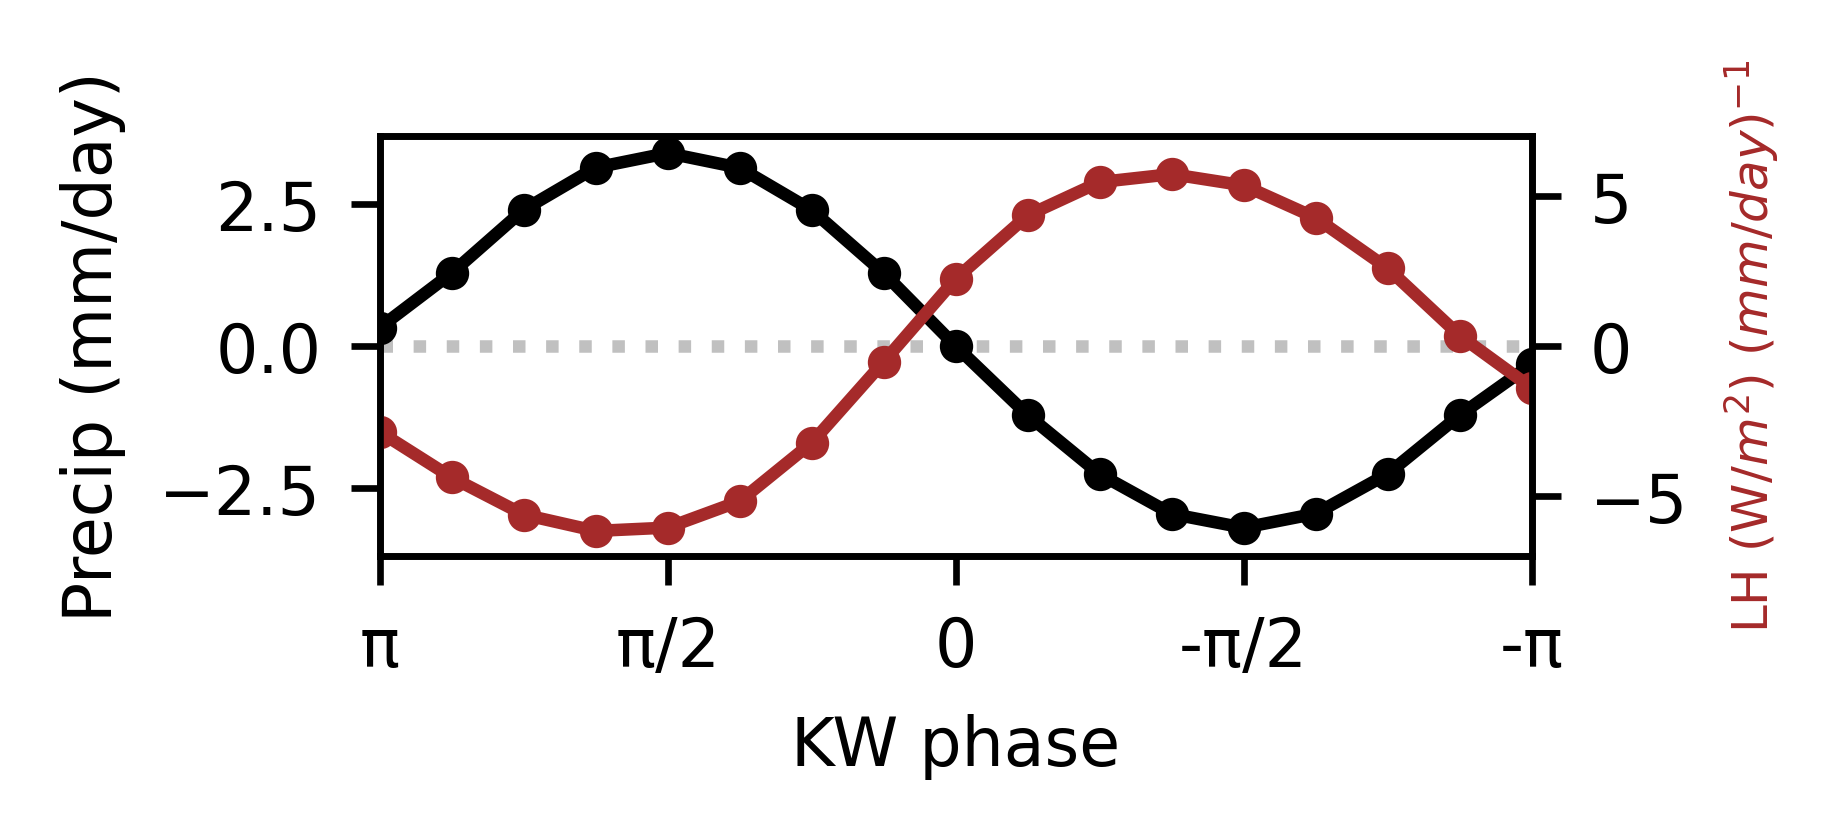

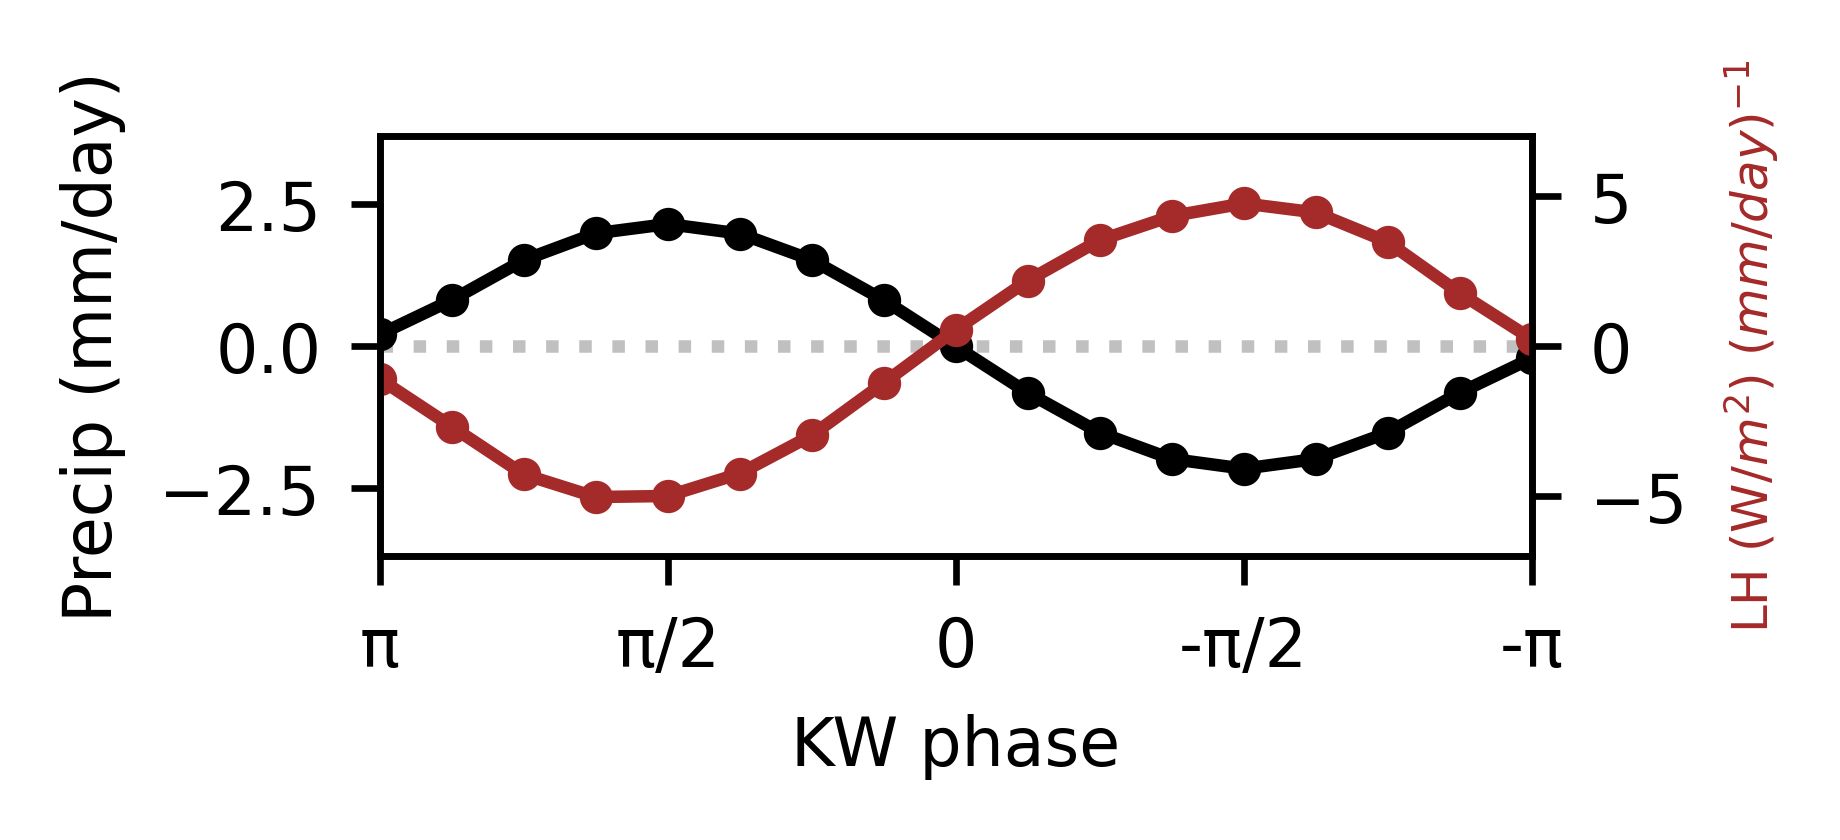

In [17]:
###############################################
# Fig.10: Plot schematic diagram (lower plot), precip and T2
######################################################
zero = np.zeros([nphase])
title = list(['-4K','CTL','+4K'])

for icase in range(0,4,2):
    fig,ax = plt.subplots(1,1,figsize=(3.2, 1.4),dpi=600)
    plt.subplots_adjust(left=0.2,right=0.8,top=0.8,bottom=0.3)
    plt.subplot(1,1,1)
    ax.plot(phase, zero, color='silver',linestyle='dotted')
    ax.plot(phase, pr_KW_all[:,icase],color='k',marker='o',markersize=3)
    ax.set_xlim([-pi,pi])
    ax.set_ylim([-3.7, 3.7])
    ax.set_ylabel('Precip (mm/day)')
    #
    ax2 = ax.twinx()
    #ax2.plot(phase, T2_lf_KW_all[:,icase],color='brown',marker='o',markersize=3) #used to be brown
    #ax2.set_ylim([-0.07, 0.06])
    #ax2.set_ylabel('T2 K $({mm/day})^{-1}$',color='brown')
    ax2.plot(phase, LH_KW_all[:,icase],color='brown',marker='o',markersize=3) #used to be brown
    ax2.set_ylim([-7, 7])
    ax2.set_ylabel('LH (W/$m^{2}$) $({mm/day})^{-1}$',color='brown', fontsize=6)    
    ax.set_xticks(np.arange(-pi,pi+pi/2,pi/2),(PI,PI+'/2','0','-'+PI+'/2','-'+PI),fontsize=font)
    ax.set_xlabel('KW phase')
    #plt.savefig(figdir+'Fig.10_pr_T2_'+title[icase]+'.png',dpi=600)
    plt.savefig(figdir+'Fig.10_pr_LH_'+title[icase]+'.png',dpi=600)
    plt.show()